# **Análisis de grandes volúmenes de datos (TC4034)**

## Maestría en Inteligencia Artificial Aplicada
### Ivan Olmos Pineda | Perla A. García Aguirre
### Tecnológico de Monterrey
## **Proyecto | Base de Datos de Big Data**

---

### Team 8

- Michelle Andrea Arceo Solano — A01625268
- Jacobo Daniel Salazar García — A01796997
- Ariel Antonio Alvarez Monroy — A01796838
- Omar Aguilar Macedo - A01797078

# Descripción del proyecto

## NYC Taxi Trip Records

## Contexto del Dataset

El dataset **NYC Taxi Trip Records** contiene información detallada sobre los viajes realizados por taxis en la ciudad de Nueva York. Cada registro representa un viaje individual e incluye variables relacionadas con tiempo, ubicación, distancia y costo del servicio.

Este dataset es ampliamente utilizado en proyectos de Big Data debido a su gran volumen, riqueza de variables y aplicabilidad en análisis de patrones urbanos, predicción y segmentación.

| Atributo         | Detalle |
|------------------|---------|
| **Nombre**       | NYC Yellow Taxi Trip Data |
| **Origen**       | Taxi & Limousine Commission (TLC) — NYC Government |
| **Fuente oficial**| https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page |
| **Diccionario de datos**| https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf |
| **Tabla de zonas (lookup)**| https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv |
| **Período a analizar**      | Enero 2023 — Marzo 2026 |
| **Tamaño total** | ~2.5 GB (139,279,754 registros, 24 columnas) |
| **Tamaño por archivo mensual** | ~45MB - 70MB (Parquet)   |
| **Formato**      | parquet |




## Tipos de Datos Disponibles

El dataset está dividido en diferentes categorías según el tipo de servicio:

- Yellow Taxi Trips  
- Green Taxi Trips  
- For-Hire Vehicle (FHV) Trips  
- High Volume FHV (Uber, Lyft, etc.)

Para este proyecto se seleccionó: **Yellow Taxi Trips**

## Formato y Acceso

Los datos están disponibles en formato `Parquet`

Este formato resulta eficiente, ya que se puede comprimir, permite lectura de columnas, y tiene un mejor rendimiento al usarse con PySpark

Ejemplo de archivo:
- https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet



# Preparación del entorno

In [1]:
# @title Dataset Imports
import os
import requests
from pathlib import Path

In [2]:
# @title Conectar a google drive
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
#@title Validación de Java
!java --version
!which java

openjdk 17.0.18 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
/usr/bin/java


In [4]:
#@title Agregamos JAVA_HOME

# Solo para linux :S, por lo que funciona en colab
JAVA_HOME=!java -XshowSettings:properties -version 2>&1 > /dev/null | grep 'java.home' | awk '{print $NF}'
JAVA_HOME=JAVA_HOME[0] # El comando anterior regresa un arreglo
%env JAVA_HOME=$JAVA_HOME

env: JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64


In [5]:
#@title Configuración e instalación de PySpark
!pip install pyspark
!pip install findspark

In [6]:
#@title PySpark imports
import findspark
from pyspark.sql import SparkSession

from pyspark.sql import functions as F
from pyspark.sql import types as T
from functools import reduce
import glob

# Para cargar algunos datasets estadísticos simples
import pandas as pd

# Para crear graficos simples
import matplotlib.pyplot as plt

# Descarga y lectura del dataset

In [7]:
# @title Descargar Dataset

# drive_dir = "/content/drive/MyDrive/TC4034_BigData/proyecto/taxi/yellow"

drive_dir = '/content/drive/MyDrive/TC4034.10 - Análisis de grandes volúmenes de datos (Gpo 10) | Equipo 8/raw/taxi/yellow'

In [8]:
#@title Leer el dataset

spark = (
    SparkSession.builder
    .appName("NYC Yellow Taxi")
    .getOrCreate()
)

# clean folder contains the parquet with the dataset with modifications
df = spark.read.parquet(f"{drive_dir}/clean")

In [9]:
#@title Esquema
df.printSchema()

root
 |-- VendorID: byte (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: byte (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- RatecodeID: byte (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- DOLocationID: short (nullable = true)
 |-- payment_type: byte (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- congestion_surcharge: float (nullable = true)
 |-- Airport_fee: float (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- pickup_year: short (nullable = true)
 |-- pickup_month: byte (nullable = true)
 |-- pick

In [10]:
#@title Muestra 10 registros
df.limit(10).toPandas()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes
0,1,2023-05-01 00:33:13,2023-05-01 00:53:01,0,7.80,1,N,138,43,1,...,0.00,1.0,51.650002,0.0,1.75,NaN,2023,5,0,19.8
1,1,2023-05-01 00:42:49,2023-05-01 01:11:18,2,8.10,1,N,138,262,1,...,0.00,1.0,57.150002,2.5,1.75,NaN,2023,5,0,28.5
2,1,2023-05-01 00:56:34,2023-05-01 01:13:39,2,9.10,1,N,138,141,1,...,6.55,1.0,64.199997,2.5,1.75,NaN,2023,5,0,17.1
3,2,2023-05-01 00:00:52,2023-05-01 00:20:12,1,8.21,1,N,138,140,1,...,0.00,1.0,47.090000,2.5,1.75,NaN,2023,5,0,19.3
4,1,2023-05-01 00:05:50,2023-05-01 00:19:41,0,7.90,1,N,138,263,1,...,6.55,1.0,59.150002,2.5,1.75,NaN,2023,5,0,13.9
5,1,2023-05-01 00:42:54,2023-05-01 01:04:49,0,10.40,1,N,138,246,1,...,6.55,1.0,69.000000,2.5,1.75,NaN,2023,5,0,21.9
6,2,2023-05-01 00:50:34,2023-05-01 01:12:09,1,9.05,1,N,138,116,1,...,6.55,1.0,64.559998,0.0,1.75,NaN,2023,5,0,21.6
7,1,2023-05-01 00:13:58,2023-05-01 00:18:10,1,0.70,1,N,161,48,1,...,0.00,1.0,14.350000,2.5,0.00,NaN,2023,5,0,4.2
8,2,2023-04-30 23:48:31,2023-04-30 23:57:35,1,2.38,1,N,249,231,2,...,0.00,1.0,17.100000,2.5,0.00,NaN,2023,4,23,9.1
9,2,2023-05-01 00:28:47,2023-05-01 00:39:33,1,2.92,1,N,114,230,2,...,0.00,1.0,19.900000,2.5,0.00,NaN,2023,5,0,10.8


In [11]:
#@title Dimensiones generales

total_records = df.count()
total_columns = len(df.columns)
size_in_bytes = df._jdf.queryExecution().optimizedPlan().stats().sizeInBytes()
print(f"Número de registros: {total_records:,}")
print(f"Información de columnas: {total_columns}")
print(f"Tamaño aproximado: ~{(size_in_bytes / 1024 / 1024 / 1024):.02f} GB")


Número de registros: 139,279,754
Información de columnas: 24
Tamaño aproximado: ~2.87 GB


# Particionamiento

In [12]:
#@title Descargar archivo auxiliar de zonas para análisis

import os
import requests

zones_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zones_path = f"{drive_dir}/taxi_zone_lookup.csv"

if not os.path.exists(zones_path):
    response = requests.get(zones_url)
    response.raise_for_status()

    with open(zones_path, "wb") as f:
        f.write(response.content)

    print("Archivo descargado correctamente:")
    print(zones_path)
else:
    print("El archivo ya existe:")
    print(zones_path)

El archivo ya existe:
/content/drive/MyDrive/TC4034.10 - Análisis de grandes volúmenes de datos (Gpo 10) | Equipo 8/raw/taxi/yellow/taxi_zone_lookup.csv


## Caracterización de la Población

## Integración de información geográfica de zonas de recogida

In [13]:

zones = spark.read.csv(zones_path, header=True, inferSchema=True)

zones_pickup = (
    zones
      .select(
          F.col("LocationID").cast("int").alias("PULocationID"),
          F.col("Borough").alias("pickup_borough"),
          F.col("Zone").alias("pickup_zone")
      )
)

df_with_zone = df.join(zones_pickup, on="PULocationID", how="left")

## Reglas de particionamiento

El particionamiento se aplica sobre el subconjunto Manhattan y combina
dos variables derivadas:

- **Origen**: solo viajes con pickup_borough = 'Manhattan'
- **Distancia** (`trip_distance_bucket`)
    - corto si `trip_distance` <= 2 mi,
    - medio si <= 10 mi
    - largo si > 10 mi
- **Franja horaria** (`pickup_hour_bucket`)
    - `primera_mitad_dia` para horas 0-11,
    - `segunda_mitad_dia` para horas 12-23



In [14]:
#Zona Origen: Manhattan
#Distancia de viaje: corto (<= 2 mi), medio (<= 10 mi), largo (> 10 mi)
#Franja horaria: primera_mitad_dia (0-11 h), segunda_mitad_dia (12-23 h)

df_partitioned = (
    df_with_zone
      .filter(F.col("pickup_borough") == "Manhattan")

      .withColumn(
          "trip_distance_bucket",
          F.when(F.col("trip_distance") <= 2, "corto")
          .when(F.col("trip_distance") <= 10, "medio")
          .otherwise("largo")
      )

      .withColumn(
          "pickup_hour_bucket",
          F.when((F.col("pickup_hour") >= 0) & (F.col("pickup_hour") <= 11), "primera_mitad_dia")
          .otherwise("segunda_mitad_dia")
      )
)

## Visualización




In [15]:
#@title Viajes por horario y duración
partitions = (
    df_partitioned
    .groupBy("pickup_hour_bucket", "trip_distance_bucket")
    .count()
    .orderBy("pickup_hour_bucket", "trip_distance_bucket")
)

partitions.show()

+------------------+--------------------+--------+
|pickup_hour_bucket|trip_distance_bucket|   count|
+------------------+--------------------+--------+
| primera_mitad_dia|               corto|21154388|
| primera_mitad_dia|               largo| 1282015|
| primera_mitad_dia|               medio|13535201|
| segunda_mitad_dia|               corto|53404297|
| segunda_mitad_dia|               largo| 1937647|
| segunda_mitad_dia|               medio|30196831|
+------------------+--------------------+--------+



In [16]:
#@title Distribución porcentual de viajes por horario y duración
total_rows = df_partitioned.count()

partition_stats = (
    partitions
      .withColumn(
          "probability",
          F.round(
              (F.col("count") / F.lit(total_rows)) * 100,
              2
          )
      )
)

partition_stats.show()

+------------------+--------------------+--------+-----------+
|pickup_hour_bucket|trip_distance_bucket|   count|probability|
+------------------+--------------------+--------+-----------+
| primera_mitad_dia|               corto|21154388|      17.41|
| primera_mitad_dia|               largo| 1282015|       1.06|
| primera_mitad_dia|               medio|13535201|      11.14|
| segunda_mitad_dia|               corto|53404297|      43.95|
| segunda_mitad_dia|               largo| 1937647|       1.59|
| segunda_mitad_dia|               medio|30196831|      24.85|
+------------------+--------------------+--------+-----------+



In [17]:
#@title Muestra de viajes cortos en la primera mitad del día (P1)
sample_p1 = (
    df_partitioned
    .filter(
        (F.col("pickup_hour_bucket") == "primera_mitad_dia") &
        (F.col("trip_distance_bucket") == "corto")
    )
    .limit(1000)
)

sample_p1.limit(10).toPandas()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes,pickup_borough,pickup_zone,trip_distance_bucket,pickup_hour_bucket
0,161,1,2023-05-01 00:13:58,2023-05-01 00:18:10,1,0.70,1,N,48,1,...,0.0,NaN,2023,5,0,4.2,Manhattan,Midtown Center,corto,primera_mitad_dia
1,230,2,2023-05-01 00:55:22,2023-05-01 00:58:20,1,1.19,1,N,100,1,...,0.0,NaN,2023,5,0,3.0,Manhattan,Times Sq/Theatre District,corto,primera_mitad_dia
2,107,1,2023-05-01 00:07:05,2023-05-01 00:08:45,1,0.60,1,N,170,3,...,0.0,NaN,2023,5,0,1.7,Manhattan,Gramercy,corto,primera_mitad_dia
3,162,1,2023-05-01 00:30:56,2023-05-01 00:36:33,1,1.90,1,N,236,1,...,0.0,NaN,2023,5,0,5.6,Manhattan,Midtown East,corto,primera_mitad_dia
4,186,2,2023-05-01 00:53:26,2023-05-01 00:57:47,1,0.60,1,N,100,2,...,0.0,NaN,2023,5,0,4.4,Manhattan,Penn Station/Madison Sq West,corto,primera_mitad_dia
5,148,1,2023-05-01 00:34:39,2023-05-01 00:45:59,1,1.60,1,N,249,1,...,0.0,NaN,2023,5,0,11.3,Manhattan,Lower East Side,corto,primera_mitad_dia
6,48,2,2023-05-01 00:02:13,2023-05-01 00:09:26,1,1.73,1,N,186,1,...,0.0,NaN,2023,5,0,7.2,Manhattan,Clinton East,corto,primera_mitad_dia
7,186,2,2023-05-01 00:10:47,2023-05-01 00:15:01,2,0.61,1,N,90,1,...,0.0,NaN,2023,5,0,4.2,Manhattan,Penn Station/Madison Sq West,corto,primera_mitad_dia
8,249,2,2023-05-01 00:30:22,2023-05-01 00:36:54,3,1.06,1,N,234,4,...,0.0,NaN,2023,5,0,6.5,Manhattan,West Village,corto,primera_mitad_dia
9,249,2,2023-05-01 00:30:22,2023-05-01 00:36:54,3,1.06,1,N,234,4,...,0.0,NaN,2023,5,0,6.5,Manhattan,West Village,corto,primera_mitad_dia


In [18]:
#@title Muestra de viajes cortos en la segunda mitad del día (P2)
sample_second_half_short = (
    df_partitioned
    .filter(
        (F.col("pickup_hour_bucket") == "segunda_mitad_dia") &
        (F.col("trip_distance_bucket") == "corto")
    )
    .limit(1000)
)

sample_second_half_short.limit(10).toPandas()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes,pickup_borough,pickup_zone,trip_distance_bucket,pickup_hour_bucket
0,68,2,2023-04-30 23:59:43,2023-05-01 00:07:57,6,1.61,1,N,161,1,...,0.0,NaN,2023,4,23,8.2,Manhattan,East Chelsea,corto,segunda_mitad_dia
1,90,2,2023-04-30 23:58:45,2023-05-01 00:11:09,1,1.88,1,N,170,2,...,0.0,NaN,2023,4,23,12.4,Manhattan,Flatiron,corto,segunda_mitad_dia
2,170,2,2023-04-30 23:50:23,2023-04-30 23:55:42,1,1.16,1,N,48,1,...,0.0,NaN,2023,4,23,5.3,Manhattan,Murray Hill,corto,segunda_mitad_dia
3,90,2,2023-05-01 12:00:31,2023-05-01 12:11:21,1,1.38,1,N,211,1,...,0.0,NaN,2023,5,12,10.8,Manhattan,Flatiron,corto,segunda_mitad_dia
4,229,2,2023-05-01 12:05:37,2023-05-01 12:16:37,1,0.87,1,N,161,1,...,0.0,NaN,2023,5,12,11.0,Manhattan,Sutton Place/Turtle Bay North,corto,segunda_mitad_dia
5,170,2,2023-05-01 12:01:13,2023-05-01 12:07:21,1,0.63,1,N,161,2,...,0.0,NaN,2023,5,12,6.1,Manhattan,Murray Hill,corto,segunda_mitad_dia
6,107,2,2023-05-01 12:29:31,2023-05-01 12:51:49,2,1.48,1,N,100,1,...,0.0,NaN,2023,5,12,22.3,Manhattan,Gramercy,corto,segunda_mitad_dia
7,107,2,2023-05-01 12:01:35,2023-05-01 12:08:49,3,1.29,1,N,144,1,...,0.0,NaN,2023,5,12,7.2,Manhattan,Gramercy,corto,segunda_mitad_dia
8,140,2,2023-05-01 12:01:18,2023-05-01 12:14:19,1,1.33,1,N,162,1,...,0.0,NaN,2023,5,12,13.0,Manhattan,Lenox Hill East,corto,segunda_mitad_dia
9,164,2,2023-05-01 12:01:41,2023-05-01 12:20:58,1,1.35,1,N,161,1,...,0.0,NaN,2023,5,12,19.3,Manhattan,Midtown South,corto,segunda_mitad_dia


In [19]:
#@title Muestra de viajes de distancia media en la primera mitad del día (P3)
sample_p3 = (
    df_partitioned
    .filter(
        (F.col("pickup_hour_bucket") == "primera_mitad_dia") &
        (F.col("trip_distance_bucket") == "medio")
    )
    .limit(1000)
)

sample_p3.limit(10).toPandas()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes,pickup_borough,pickup_zone,trip_distance_bucket,pickup_hour_bucket
0,114,2,2023-05-01 00:28:47,2023-05-01 00:39:33,1,2.92,1,N,230,2,...,0.0,NaN,2023,5,0,10.8,Manhattan,Greenwich Village South,medio,primera_mitad_dia
1,170,2,2023-05-01 00:28:12,2023-05-01 00:36:09,1,2.30,1,N,140,1,...,0.0,NaN,2023,5,0,8.0,Manhattan,Murray Hill,medio,primera_mitad_dia
2,186,2,2023-05-01 00:07:58,2023-05-01 00:21:31,1,3.24,1,N,4,1,...,0.0,NaN,2023,5,0,13.6,Manhattan,Penn Station/Madison Sq West,medio,primera_mitad_dia
3,237,2,2023-05-01 00:00:48,2023-05-01 00:09:57,1,2.25,1,N,107,1,...,0.0,NaN,2023,5,0,9.2,Manhattan,Upper East Side South,medio,primera_mitad_dia
4,100,1,2023-05-01 00:03:09,2023-05-01 00:27:30,1,6.20,1,N,129,1,...,0.0,NaN,2023,5,0,24.4,Manhattan,Garment District,medio,primera_mitad_dia
5,163,2,2023-05-01 00:23:43,2023-05-01 00:33:08,1,2.19,1,N,141,1,...,0.0,NaN,2023,5,0,9.4,Manhattan,Midtown North,medio,primera_mitad_dia
6,249,1,2023-05-01 00:12:10,2023-05-01 00:22:43,1,2.70,1,N,163,2,...,0.0,NaN,2023,5,0,10.6,Manhattan,West Village,medio,primera_mitad_dia
7,161,1,2023-05-01 00:02:01,2023-05-01 00:25:59,1,6.30,1,N,255,1,...,0.0,NaN,2023,5,0,24.0,Manhattan,Midtown Center,medio,primera_mitad_dia
8,107,1,2023-05-01 00:21:11,2023-05-01 00:39:53,1,5.10,1,N,7,1,...,0.0,NaN,2023,5,0,18.7,Manhattan,Gramercy,medio,primera_mitad_dia
9,141,2,2023-05-01 00:07:29,2023-05-01 00:14:30,1,2.37,1,N,145,1,...,0.0,NaN,2023,5,0,7.0,Manhattan,Lenox Hill West,medio,primera_mitad_dia


In [20]:
#@title Muestra de viajes de distancia media en la segunda mitad del día (P4)
sample_p4 = (
    df_partitioned
    .filter(
        (F.col("pickup_hour_bucket") == "segunda_mitad_dia") &
        (F.col("trip_distance_bucket") == "medio")
    )
    .limit(1000)
)

sample_p4.limit(10).toPandas()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes,pickup_borough,pickup_zone,trip_distance_bucket,pickup_hour_bucket
0,249,2,2023-04-30 23:48:31,2023-04-30 23:57:35,1,2.38,1,N,231,2,...,0.0,NaN,2023,4,23,9.1,Manhattan,West Village,medio,segunda_mitad_dia
1,230,2,2023-04-30 23:58:11,2023-05-01 00:18:19,5,6.49,1,N,244,1,...,0.0,NaN,2023,4,23,20.1,Manhattan,Times Sq/Theatre District,medio,segunda_mitad_dia
2,163,2,2023-05-01 13:58:29,2023-05-01 14:21:12,1,3.94,1,N,231,2,...,0.0,NaN,2023,5,13,22.7,Manhattan,Midtown North,medio,segunda_mitad_dia
3,43,2,2023-05-01 12:01:22,2023-05-01 12:13:52,2,2.09,1,N,163,2,...,0.0,NaN,2023,5,12,12.5,Manhattan,Central Park,medio,segunda_mitad_dia
4,186,2,2023-05-01 12:08:17,2023-05-01 12:44:45,1,4.07,1,N,263,1,...,0.0,NaN,2023,5,12,36.5,Manhattan,Penn Station/Madison Sq West,medio,segunda_mitad_dia
5,231,2,2023-05-01 12:01:04,2023-05-01 12:17:34,1,6.98,1,N,233,1,...,0.0,NaN,2023,5,12,16.5,Manhattan,TriBeCa/Civic Center,medio,segunda_mitad_dia
6,186,2,2023-05-01 12:00:57,2023-05-01 12:34:16,1,5.52,1,N,87,1,...,0.0,NaN,2023,5,12,33.3,Manhattan,Penn Station/Madison Sq West,medio,segunda_mitad_dia
7,163,2,2023-05-01 12:00:33,2023-05-01 12:11:13,2,2.05,1,N,246,1,...,0.0,NaN,2023,5,12,10.7,Manhattan,Midtown North,medio,segunda_mitad_dia
8,48,1,2023-05-01 12:05:29,2023-05-01 12:22:14,1,2.20,1,N,238,2,...,0.0,NaN,2023,5,12,16.8,Manhattan,Clinton East,medio,segunda_mitad_dia
9,239,1,2023-05-01 12:27:01,2023-05-01 12:51:24,1,3.90,1,N,244,1,...,0.0,NaN,2023,5,12,24.4,Manhattan,Upper West Side South,medio,segunda_mitad_dia


In [21]:
#@title Muestra de viajes largos en la primera mitad del día (P5)
sample_p5 = (
    df_partitioned
    .filter(
        (F.col("pickup_hour_bucket") == "primera_mitad_dia") &
        (F.col("trip_distance_bucket") == "largo")
    )
    .limit(1000)
)

sample_p5.limit(10).toPandas()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes,pickup_borough,pickup_zone,trip_distance_bucket,pickup_hour_bucket
0,164,2,2023-05-01 00:19:15,2023-05-01 00:41:20,1,10.830000,1,N,67,2,...,0.0,NaN,2023,5,0,22.1,Manhattan,Midtown South,largo,primera_mitad_dia
1,50,2,2023-05-01 00:53:11,2023-05-01 01:13:20,1,13.760000,1,N,265,2,...,0.0,NaN,2023,5,0,20.2,Manhattan,Clinton West,largo,primera_mitad_dia
2,239,2,2023-05-01 00:34:28,2023-05-01 01:06:47,1,14.550000,1,N,169,1,...,0.0,NaN,2023,5,0,32.3,Manhattan,Upper West Side South,largo,primera_mitad_dia
3,161,2,2023-05-01 00:25:00,2023-05-01 00:55:28,1,10.820000,1,N,69,1,...,0.0,NaN,2023,5,0,30.5,Manhattan,Midtown Center,largo,primera_mitad_dia
4,148,1,2023-05-01 00:30:35,2023-05-01 00:56:08,1,14.100000,1,N,21,1,...,0.0,NaN,2023,5,0,25.6,Manhattan,Lower East Side,largo,primera_mitad_dia
5,230,2,2023-05-01 00:18:27,2023-05-01 00:48:44,1,10.630000,1,N,258,1,...,0.0,NaN,2023,5,0,30.3,Manhattan,Times Sq/Theatre District,largo,primera_mitad_dia
6,48,2,2023-05-01 00:32:03,2023-05-01 00:57:35,1,11.410000,1,N,241,4,...,0.0,NaN,2023,5,0,25.5,Manhattan,Clinton East,largo,primera_mitad_dia
7,48,2,2023-05-01 00:32:03,2023-05-01 00:57:35,1,11.410000,1,N,241,4,...,0.0,NaN,2023,5,0,25.5,Manhattan,Clinton East,largo,primera_mitad_dia
8,48,2,2023-05-01 00:31:54,2023-05-01 01:00:36,2,16.059999,4,N,235,2,...,0.0,NaN,2023,5,0,28.7,Manhattan,Clinton East,largo,primera_mitad_dia
9,230,2,2023-05-01 00:07:29,2023-05-01 00:36:31,1,17.639999,1,N,265,2,...,0.0,NaN,2023,5,0,29.0,Manhattan,Times Sq/Theatre District,largo,primera_mitad_dia


In [22]:
#@title Muestra de viajes largos en la segunda mitad del día (P6)
sample_p6 = (
    df_partitioned
    .filter(
        (F.col("pickup_hour_bucket") == "segunda_mitad_dia") &
        (F.col("trip_distance_bucket") == "largo")
    )
    .limit(1000)
)

sample_p6.limit(10).toPandas()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes,pickup_borough,pickup_zone,trip_distance_bucket,pickup_hour_bucket
0,144,2,2023-04-30 23:56:23,2023-05-01 00:22:30,1,13.730000,1,N,21,2,...,0.0,NaN,2023,4,23,26.1,Manhattan,Little Italy/NoLiTa,largo,segunda_mitad_dia
1,233,2,2023-05-01 12:01:31,2023-05-01 12:21:34,1,11.010000,1,N,138,1,...,0.0,NaN,2023,5,12,20.1,Manhattan,UN/Turtle Bay South,largo,segunda_mitad_dia
2,90,2,2023-05-01 12:43:45,2023-05-01 13:23:25,1,10.630000,1,N,138,1,...,0.0,NaN,2023,5,12,39.7,Manhattan,Flatiron,largo,segunda_mitad_dia
3,239,1,2023-05-01 12:09:13,2023-05-01 12:54:09,1,25.600000,2,N,132,1,...,0.0,NaN,2023,5,12,44.9,Manhattan,Upper West Side South,largo,segunda_mitad_dia
4,162,2,2023-05-01 12:26:59,2023-05-01 12:51:50,1,11.290000,1,N,138,2,...,0.0,NaN,2023,5,12,24.9,Manhattan,Midtown East,largo,segunda_mitad_dia
5,158,2,2023-05-01 12:31:38,2023-05-01 13:08:28,3,16.170000,3,N,1,1,...,0.0,NaN,2023,5,12,36.8,Manhattan,Meatpacking/West Village West,largo,segunda_mitad_dia
6,261,2,2023-05-01 12:40:33,2023-05-01 13:20:37,1,15.540000,1,N,138,1,...,0.0,NaN,2023,5,12,40.1,Manhattan,World Trade Center,largo,segunda_mitad_dia
7,151,2,2023-05-01 12:35:34,2023-05-01 13:10:13,1,20.530001,3,N,1,1,...,0.0,NaN,2023,5,12,34.7,Manhattan,Manhattan Valley,largo,segunda_mitad_dia
8,162,1,2023-05-01 12:01:47,2023-05-01 12:21:04,1,11.100000,1,N,138,1,...,0.0,NaN,2023,5,12,19.3,Manhattan,Midtown East,largo,segunda_mitad_dia
9,68,2,2023-05-01 12:50:18,2023-05-01 14:02:47,1,17.719999,2,N,132,1,...,0.0,NaN,2023,5,12,72.5,Manhattan,East Chelsea,largo,segunda_mitad_dia


In [23]:
#@title Selección de muestra proporcional por partición
sample_fraction = 0.01  # 1% de cada partición

sample = (
    df_partitioned
    .withColumn(
        "partition_key",
        F.concat_ws(
            "-",
            F.col("pickup_hour_bucket"),
            F.col("trip_distance_bucket")
        )
    )
    .sampleBy(
        "partition_key",
        fractions={
            "primera_mitad_dia-corto": sample_fraction,
            "primera_mitad_dia-medio": sample_fraction,
            "primera_mitad_dia-largo": sample_fraction,
            "segunda_mitad_dia-corto": sample_fraction,
            "segunda_mitad_dia-medio": sample_fraction,
            "segunda_mitad_dia-largo": sample_fraction,
        },
        seed=42
    )
)

In [24]:
sample.limit(10).toPandas()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes,pickup_borough,pickup_zone,trip_distance_bucket,pickup_hour_bucket,partition_key
0,41,2,2023-05-01 00:00:06,2023-05-01 00:08:55,3,1.460000,1,N,166,2,...,NaN,2023,5,0,8.8,Manhattan,Central Harlem,corto,primera_mitad_dia,primera_mitad_dia-corto
1,163,2,2023-05-01 00:51:21,2023-05-01 01:07:42,1,4.510000,1,N,151,1,...,NaN,2023,5,0,16.4,Manhattan,Midtown North,medio,primera_mitad_dia,primera_mitad_dia-medio
2,170,2,2023-05-01 00:27:10,2023-05-01 00:38:12,1,2.900000,1,N,142,1,...,NaN,2023,5,0,11.0,Manhattan,Murray Hill,medio,primera_mitad_dia,primera_mitad_dia-medio
3,246,2,2023-05-01 01:52:23,2023-05-01 02:22:58,2,12.300000,1,N,248,2,...,NaN,2023,5,1,30.6,Manhattan,West Chelsea/Hudson Yards,largo,primera_mitad_dia,primera_mitad_dia-largo
4,246,2,2023-05-01 02:36:48,2023-05-01 02:47:34,1,3.320000,1,N,141,1,...,NaN,2023,5,2,10.8,Manhattan,West Chelsea/Hudson Yards,medio,primera_mitad_dia,primera_mitad_dia-medio
5,161,2,2023-05-01 02:38:33,2023-05-01 04:00:13,4,47.119999,5,N,265,2,...,NaN,2023,5,2,81.7,Manhattan,Midtown Center,largo,primera_mitad_dia,primera_mitad_dia-largo
6,230,2,2023-05-01 02:10:17,2023-05-01 02:33:59,2,6.750000,1,N,49,1,...,NaN,2023,5,2,23.7,Manhattan,Times Sq/Theatre District,medio,primera_mitad_dia,primera_mitad_dia-medio
7,68,1,2023-05-01 03:00:32,2023-05-01 03:15:20,1,2.500000,1,N,163,1,...,NaN,2023,5,3,14.8,Manhattan,East Chelsea,medio,primera_mitad_dia,primera_mitad_dia-medio
8,100,2,2023-05-01 03:16:24,2023-05-01 03:21:28,1,1.760000,1,N,249,1,...,NaN,2023,5,3,5.1,Manhattan,Garment District,corto,primera_mitad_dia,primera_mitad_dia-corto
9,100,2,2023-05-01 03:39:25,2023-05-01 03:48:37,1,2.600000,1,N,140,2,...,NaN,2023,5,3,9.2,Manhattan,Garment District,medio,primera_mitad_dia,primera_mitad_dia-medio


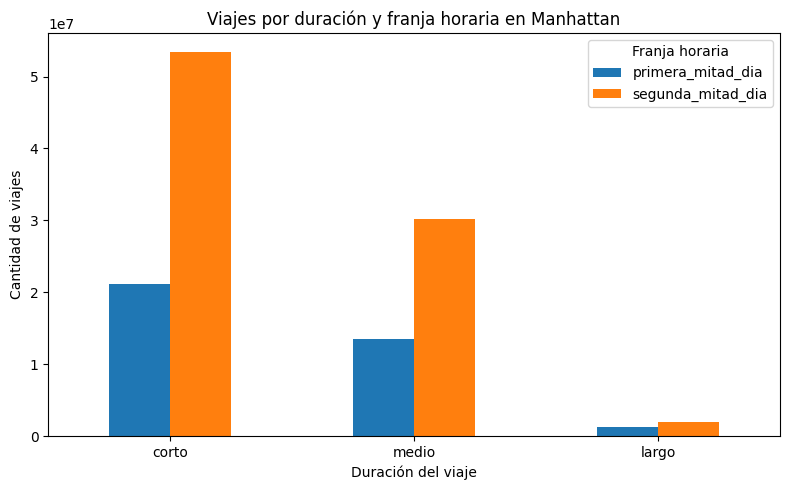

In [25]:
#@title viajes por duración y franja horaria en Manhattan
plot_counts = (
    df_partitioned
    .groupBy("pickup_hour_bucket", "trip_distance_bucket")
    .count()
    .orderBy("pickup_hour_bucket", "trip_distance_bucket")
)

plot_counts_pd = plot_counts.toPandas()

pivot_counts = plot_counts_pd.pivot(
    index="trip_distance_bucket",
    columns="pickup_hour_bucket",
    values="count"
).fillna(0)

pivot_counts = pivot_counts.reindex(["corto", "medio", "largo"])

pivot_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Viajes por duración y franja horaria en Manhattan")
plt.xlabel("Duración del viaje")
plt.ylabel("Cantidad de viajes")
plt.xticks(rotation=0)
plt.legend(title="Franja horaria")
plt.tight_layout()
plt.show()

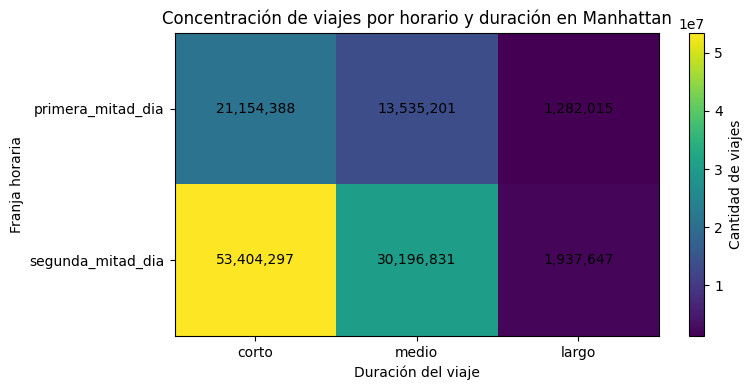

In [26]:
#@title Concentración de viajes por horario y duración en Manhattan
heatmap_data = (
    df_partitioned
    .groupBy("pickup_hour_bucket", "trip_distance_bucket")
    .count()
    .orderBy("pickup_hour_bucket", "trip_distance_bucket")
)

heatmap_pd = heatmap_data.toPandas()

heatmap_pivot = heatmap_pd.pivot(
    index="pickup_hour_bucket",
    columns="trip_distance_bucket",
    values="count"
).fillna(0)

heatmap_pivot = heatmap_pivot[["corto", "medio", "largo"]]
heatmap_pivot = heatmap_pivot.reindex([
    "primera_mitad_dia",
    "segunda_mitad_dia"
])

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_pivot, aspect="auto")

plt.title("Concentración de viajes por horario y duración en Manhattan")
plt.xlabel("Duración del viaje")
plt.ylabel("Franja horaria")

plt.xticks(
    range(len(heatmap_pivot.columns)),
    heatmap_pivot.columns
)

plt.yticks(
    range(len(heatmap_pivot.index)),
    heatmap_pivot.index
)

for i in range(len(heatmap_pivot.index)):
    for j in range(len(heatmap_pivot.columns)):
        value = int(heatmap_pivot.iloc[i, j])
        plt.text(j, i, f"{value:,}", ha="center", va="center")

plt.colorbar(label="Cantidad de viajes")
plt.tight_layout()
plt.show()